# Classification Perfomance based on Explanations

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join, abspath
from collections import Counter
import numpy as np
from os.path import join
sys.path.append("../..")


from config import DATA_DIR, ALL_GROUPS
from utils.classification_helpers import group_ihra_content, group_lexicon_content, count_items, compute_multilabel_prec_recall, plot_distribution_diff, plot_distribution_diff_pair

In [677]:
PROVIDER = "claude"

In [678]:
bloomington = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_bloomington_label_1.feather"))
decoding = pd.read_feather(join(DATA_DIR, f"{PROVIDER}_decoding_label_1.feather"))

In [ ]:
column_name_renaming = {
    'classification_ihra_explanation_cleaned': 'IHRA_c',
    'explanation_ihra_explanation_cleaned': 'IHRA_e',
    'classification_tax': 'TAX_c',
    'explanation_tax': 'TAX_e',
    'classification_tax_ex': 'TAX_EX_c',
    'explanation_tax_ex': 'TAX_EX_e',

    'explanation_ihra_explanation_sections': 'IHRA_e_sections',
    'explanation_tax_chapters': 'TAX_e_chapters',
    'explanation_tax_chapters_no': 'TAX_e_chapters_no',
    'explanation_tax_ex_chapters': 'TAX_EX_e_chapters',
    'explanation_tax_ex_chapters_no': 'TAX_EX_e_chapters_no',
    'explanation_tax_sections': 'TAX_e_sections',
    'explanation_tax_ex_sections': 'TAX_EX_e_sections',
}
bloomington.rename(columns=column_name_renaming, inplace=True)
decoding.rename(columns=column_name_renaming, inplace=True)

REL_CLASS_COLS = column_name_renaming.values()

BLOOMINGTON_DATA_COLS = ['comment_cleaned', 'keyword', 'ihra_sections']
DECODING_DATA_COLS = ['comment_cleaned', 'comment_codes_all_list', 'comment_codes_all_chapters', 'comment_codes_all_sections']

# Bloomington

### IHRA

In [680]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [681]:
len(bloomington_ihra)

1256

In [682]:
bloomington_ihra['overlap'] = bloomington_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_ihra['overlap'].mean()

np.float64(0.9211783439490446)

#### Group level

In [ ]:
bloomington_ihra['explanation_same_content_groups'] = bloomington_ihra['IHRA_e_sections_same'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [ ]:
b_ihra_groups_count, b_ihra_groups_count_norm = count_items(bloomington_ihra["annotators_content_groups"], interpret_as_int=False)
b_ihra_e_groups_count, b_ihra_e_groups_count_norm = count_items(bloomington_ihra["explanation_content_groups"], interpret_as_int=False)
b_ihra_e_groups_same_count, b_ihra_e_groups_same_count_norm = count_items(bloomington_ihra["explanation_same_content_groups"], interpret_as_int=False)

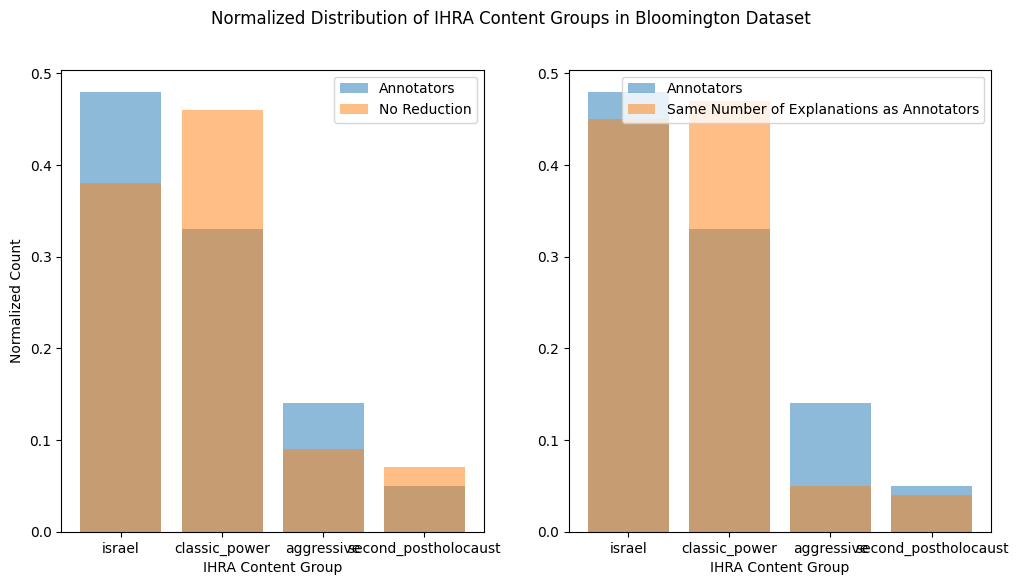

In [701]:
plot_distribution_diff_pair(
    b_ihra_groups_count_norm,
    b_ihra_e_groups_count_norm,
    b_ihra_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of IHRA Content Groups in Bloomington Dataset',
    'IHRA Content Group',
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [703]:
compute_multilabel_prec_recall(bloomington_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,208,177,78,0.375000,0.440678
1,classic_power,510,923,479,0.939216,0.518960
3,israel,729,761,676,0.927298,0.888305
2,second_postholocaust,79,138,49,0.620253,0.355072


### TAX

In [707]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax.head()

bloomington_tax['overlap'] = bloomington_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax['overlap'].mean()

np.float64(0.9425837320574163)

In [708]:
bloomington_tax["ihra_sections_cnt"] = bloomington_tax["ihra_sections"].map(len)
bloomington_tax["tax_e_chapters_cnt"] = bloomington_tax["TAX_e_chapters"].map(len)

In [709]:
b_tax_sections_count, b_tax_sections_count_norm = count_items(bloomington_tax["ihra_sections"])

In [710]:
sum(b_tax_sections_count.values())

1940

In [711]:
b_tax_e_chapters_count, b_tax_e_chapters_count_norm = count_items(bloomington_tax["TAX_e_chapters"])

In [712]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [ ]:
bloomington_tax["TAX_e_chapters_max_2"] = bloomington_tax["TAX_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_tax["TAX_e_chapters_max_2_cnt"] = bloomington_tax["TAX_e_chapters_max_2"].map(len)
bloomington_tax["TAX_e_chapters_same"] = bloomington_tax.apply(lambda x: reduce_to_same_number(x, to_reduce_col="TAX_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_tax["TAX_e_chapters_same_cnt"] = bloomington_tax["TAX_e_chapters_same"].map(len)
bloomington_tax[["ihra_sections_cnt", "tax_e_chapters_cnt", "TAX_e_chapters_max_2_cnt", "TAX_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,tax_e_chapters_cnt,TAX_e_chapters_max_2_cnt,TAX_e_chapters_same_cnt
count,1463.000000,1463.000000,1463.000000,1463.000000
mean,1.326042,3.278195,1.935748,1.312372
std,0.468923,1.354875,0.245284,0.463619
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,3.000000,2.000000,1.000000
75%,2.000000,4.000000,2.000000,2.000000
max,2.000000,9.000000,2.000000,2.000000


In [ ]:
bloomington_tax['explanation_same_content_groups'] = bloomington_tax['TAX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_tax_groups_count, b_tax_groups_count_norm = count_items(bloomington_tax["annotators_content_groups"], interpret_as_int=False)
b_tax_e_groups_count, b_tax_e_groups_count_norm = count_items(bloomington_tax["explanation_content_groups"], interpret_as_int=False)
b_tax_e_groups_same_count, b_tax_e_groups_same_count_norm = count_items(bloomington_tax["explanation_same_content_groups"], interpret_as_int=False)

In [717]:
b_tax_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

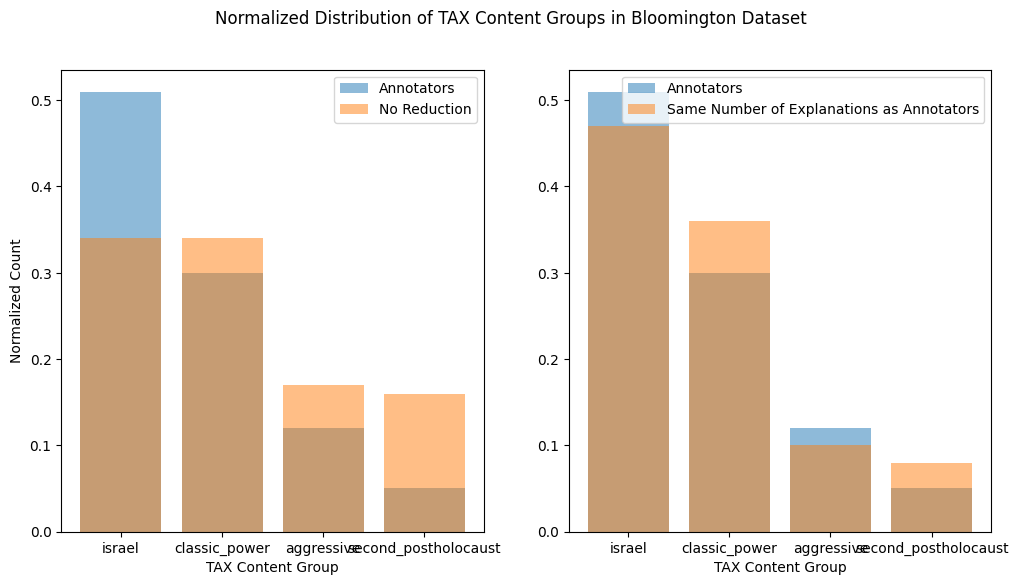

In [721]:
plot_distribution_diff_pair(
    b_tax_groups_count_norm,
    b_tax_e_groups_count_norm,
    b_tax_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of TAX Content Groups in Bloomington Dataset',
    'TAX Content Group',
    normalized=True)

In [722]:
compute_multilabel_prec_recall(bloomington_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,211,457,161,0.763033,0.352298
1,classic_power,527,928,479,0.908918,0.516164
3,israel,914,939,853,0.933260,0.908413
2,second_postholocaust,86,443,69,0.802326,0.155756


### TAX EX

In [725]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex.head()

bloomington_tax_ex['overlap'] = bloomington_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
bloomington_tax_ex['overlap'].mean()

np.float64(0.923896499238965)

In [726]:
bloomington_tax_ex["ihra_sections_cnt"] = bloomington_tax_ex["ihra_sections"].map(len)
bloomington_tax_ex["tax_ex_e_chapters_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(len)

In [727]:
b_tax_ex_sections_count, b_tax_ex_sections_count_norm = count_items(bloomington_tax_ex["ihra_sections"])

In [728]:
sum(b_tax_ex_sections_count.values())

1753

In [729]:
b_tax_ex_e_chapters_count, b_tax_ex_e_chapters_count_norm = count_items(bloomington_tax_ex["TAX_EX_e_chapters"])

In [730]:
def reduce_to_same_number(row, to_reduce_col, reference_col):
    if len(row[to_reduce_col]) > 0:
        if row[reference_col] == len(row[to_reduce_col]):
            return row[to_reduce_col]
        else:
            return row[to_reduce_col][:row[reference_col]]
    else:
        return row[to_reduce_col]


In [731]:
bloomington_tax_ex["TAX_EX_e_chapters_max_2"] = bloomington_tax_ex["TAX_EX_e_chapters"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
bloomington_tax_ex["TAX_EX_e_chapters_max_2_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters_max_2"].map(len)
bloomington_tax_ex["TAX_EX_e_chapters_same"] = bloomington_tax_ex.apply(lambda x: reduce_to_same_number(x, to_reduce_col="TAX_EX_e_chapters", reference_col="ihra_sections_cnt"), axis=1)
bloomington_tax_ex["TAX_EX_e_chapters_same_cnt"] = bloomington_tax_ex["TAX_EX_e_chapters_same"].map(len)
bloomington_tax_ex[["ihra_sections_cnt", "tax_ex_e_chapters_cnt", "TAX_EX_e_chapters_max_2_cnt", "TAX_EX_e_chapters_same_cnt"]].describe()

,ihra_sections_cnt,tax_ex_e_chapters_cnt,TAX_EX_e_chapters_max_2_cnt,TAX_EX_e_chapters_same_cnt
count,1314.000000,1314.000000,1314.000000,1314.000000
mean,1.334094,3.031202,1.921613,1.317352
std,0.471852,1.319985,0.268881,0.465623
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,3.000000,2.000000,1.000000
75%,2.000000,4.000000,2.000000,2.000000
max,2.000000,10.000000,2.000000,2.000000


In [ ]:
bloomington_tax_ex['explanation_same_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
b_tax_ex_groups_count, b_tax_ex_groups_count_norm = count_items(bloomington_tax_ex["annotators_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_count, b_tax_ex_e_groups_count_norm = count_items(bloomington_tax_ex["explanation_content_groups"], interpret_as_int=False)
b_tax_ex_e_groups_same_count, b_tax_ex_e_groups_same_count_norm = count_items(bloomington_tax_ex["explanation_same_content_groups"], interpret_as_int=False)

In [735]:
b_tax_ex_groups_count = {key: value for key, value in b_tax_groups_count.items() if key in ALL_GROUPS}
b_tax_ex_groups_count_norm = {key: value for key, value in b_tax_groups_count_norm.items() if key in ALL_GROUPS}

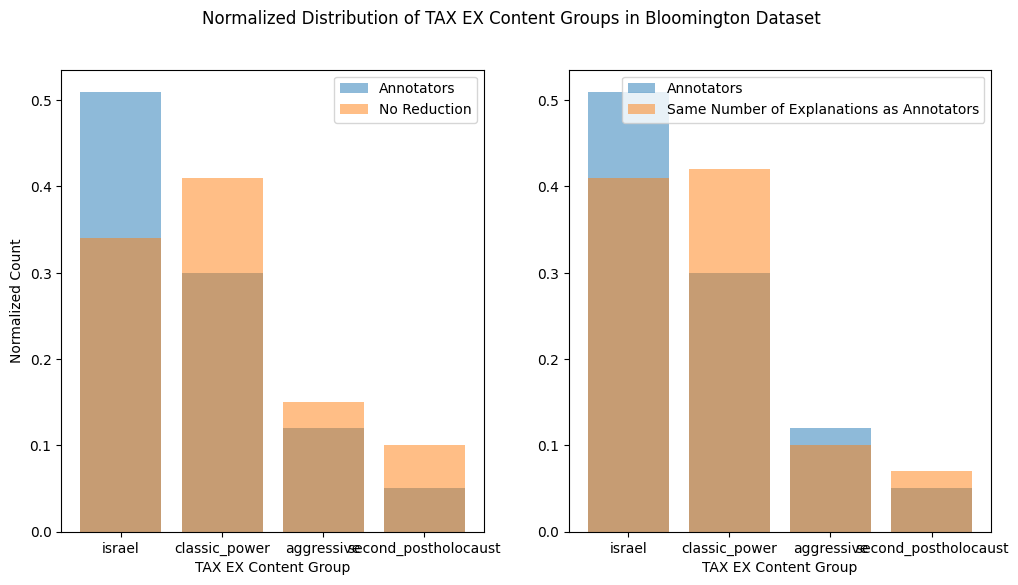

In [739]:
plot_distribution_diff_pair(
    b_tax_ex_groups_count_norm,
    b_tax_ex_e_groups_count_norm,
    b_tax_ex_e_groups_same_count_norm,
    'No Reduction',
    'Same Number of Explanations as Annotators',
    'Normalized Distribution of TAX EX Content Groups in Bloomington Dataset',
    'TAX EX Content Group',
    normalized=True)

In [740]:
compute_multilabel_prec_recall(bloomington_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,205,346,132,0.643902,0.381503
1,classic_power,507,940,474,0.934911,0.504255
3,israel,789,770,719,0.911280,0.933766
2,second_postholocaust,76,239,53,0.697368,0.221757


# Decoding

### IHRA

Can be compared on the level of groups only

In [746]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]

In [747]:
decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra.tail()

decoding_ihra['overlap'] = decoding_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_ihra['overlap'].mean()

np.float64(0.8923293455313159)

In [748]:
decoding_ihra["lexicon_chapters_cnt"] = decoding_ihra["comment_codes_all_chapters"].map(len)
decoding_ihra["IHRA_e_sections_cnt"] = decoding_ihra["IHRA_e_sections"].map(len)

In [749]:
d_ihra_chapters_count, d_ihra_chapters_count_norm = count_items(decoding_ihra["comment_codes_all_chapters"])
#sum(d_ihra_chapters_count.values())

In [750]:
d_ihra_e_sections_count, d_ihra_e_sections_count_norm = count_items(decoding_ihra["IHRA_e_sections"])

In [751]:
decoding_ihra["IHRA_e_sections_max_2"] = decoding_ihra["IHRA_e_sections"].map(lambda x: [x[0], x[1] ] if len(x)>2 else x)
decoding_ihra["IHRA_e_sections_max_2_cnt"] = decoding_ihra["IHRA_e_sections_max_2"].map(len)
decoding_ihra["IHRA_e_sections_same"] = decoding_ihra.apply(lambda x: reduce_to_same_number(x, to_reduce_col="IHRA_e_sections", reference_col="lexicon_chapters_cnt"), axis=1)
decoding_ihra["IHRA_e_sections_same_cnt"] = decoding_ihra["IHRA_e_sections_same"].map(len)
decoding_ihra[["lexicon_chapters_cnt", "IHRA_e_sections_cnt", "IHRA_e_sections_max_2_cnt", "IHRA_e_sections_same_cnt"]].describe()

,lexicon_chapters_cnt,IHRA_e_sections_cnt,IHRA_e_sections_max_2_cnt,IHRA_e_sections_same_cnt
count,1421.000000,1421.000000,1421.000000,1421.000000
mean,1.592540,2.118227,1.777621,1.387051
std,0.987628,0.829109,0.415991,0.674026
min,0.000000,1.000000,1.000000,0.000000
25%,1.000000,2.000000,2.000000,1.000000
50%,1.000000,2.000000,2.000000,1.000000
75%,2.000000,3.000000,2.000000,2.000000
max,8.000000,5.000000,2.000000,5.000000


In [ ]:
decoding_ihra['explanation_same_content_groups'] = decoding_ihra['IHRA_e_sections_same'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))

In [ ]:
d_ihra_groups_count, d_ihra_groups_count_norm = count_items(decoding_ihra["annotators_content_groups"], interpret_as_int=False)
d_ihra_e_groups_count, d_ihra_e_groups_count_norm = count_items(decoding_ihra["explanation_content_groups"], interpret_as_int=False)
d_ihra_e_groups_same_count, d_ihra_e_groups_same_count_norm = count_items(decoding_ihra["explanation_same_content_groups"], interpret_as_int=False)

In [758]:
d_ihra_e_groups_count = {key: value for key, value in d_ihra_e_groups_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_count_norm = {key: value for key, value in d_ihra_e_groups_count_norm.items() if key in ALL_GROUPS}

d_ihra_e_groups_same_count = {key: value for key, value in d_ihra_e_groups_same_count.items() if key in ALL_GROUPS}
d_ihra_e_groups_same_count_norm = {key: value for key, value in d_ihra_e_groups_same_count_norm.items() if key in ALL_GROUPS}

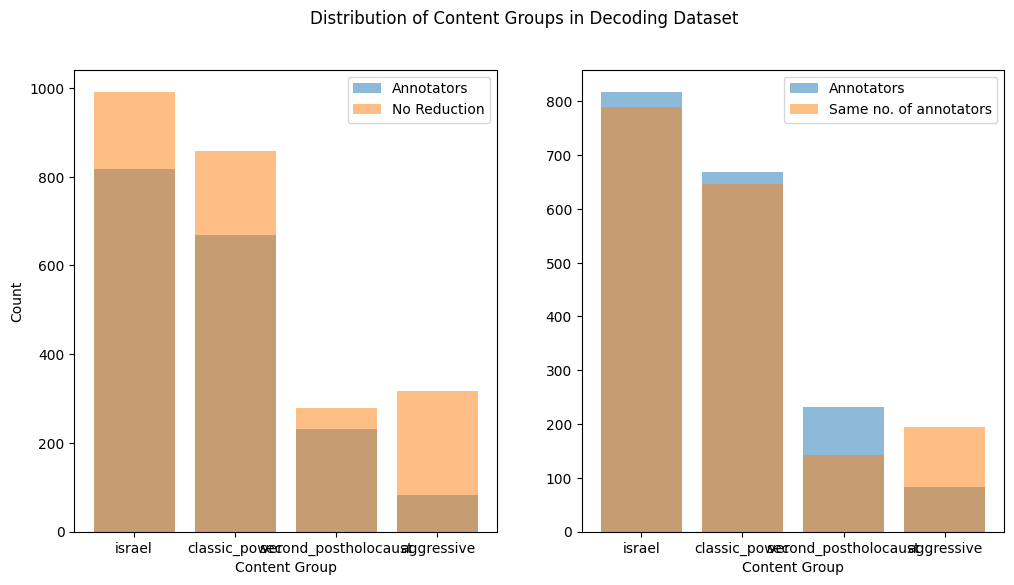

In [760]:
plot_distribution_diff_pair(
    d_ihra_groups_count,
    d_ihra_e_groups_count,
    d_ihra_e_groups_same_count,
    'No Reduction',
    'Same no. of annotators',
    'Distribution of Content Groups in Decoding Dataset',
    'Content Group',
    normalized=False)

In [761]:
compute_multilabel_prec_recall(decoding_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,82,316,61,0.743902,0.193038
1,classic_power,669,859,559,0.835575,0.650757
3,israel,818,992,761,0.930318,0.767137
2,second_postholocaust,231,278,90,0.389610,0.323741


### TAX

In [764]:
decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax.head()

decoding_tax['overlap'] = decoding_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax['overlap'].mean()

np.float64(0.9162929745889388)

In [765]:
decoding_tax["tax_chapters_cnt"] = decoding_tax["comment_codes_all_chapters"].map(len)
decoding_tax["tax_e_chapters_cnt"] = decoding_tax["TAX_e_chapters"].map(len)
decoding_tax[["tax_chapters_cnt", "tax_e_chapters_cnt"]].describe()

,tax_chapters_cnt,tax_e_chapters_cnt
count,2007.000000,2007.000000
mean,1.577977,3.480319
std,0.950821,1.566564
min,0.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,3.000000
75%,2.000000,4.000000
max,8.000000,12.000000


In [766]:
d_tax_chapters_count, d_tax_chapters_count_norm = count_items(decoding_tax["comment_codes_all_chapters"])
sum(d_tax_chapters_count.values())

3167

#### Group level

In [ ]:
decoding_tax['explanation_same_content_groups'] = decoding_tax['TAX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
d_tax_groups_count, d_tax_groups_count_norm = count_items(decoding_tax["annotators_content_groups"], interpret_as_int=False)
d_tax_e_groups_count, d_tax_e_groups_count_norm = count_items(decoding_tax["explanation_content_groups"], interpret_as_int=False)
d_tax_e_groups_same_count, d_tax_e_groups_same_count_norm = count_items(decoding_tax["explanation_same_content_groups"], interpret_as_int=False)

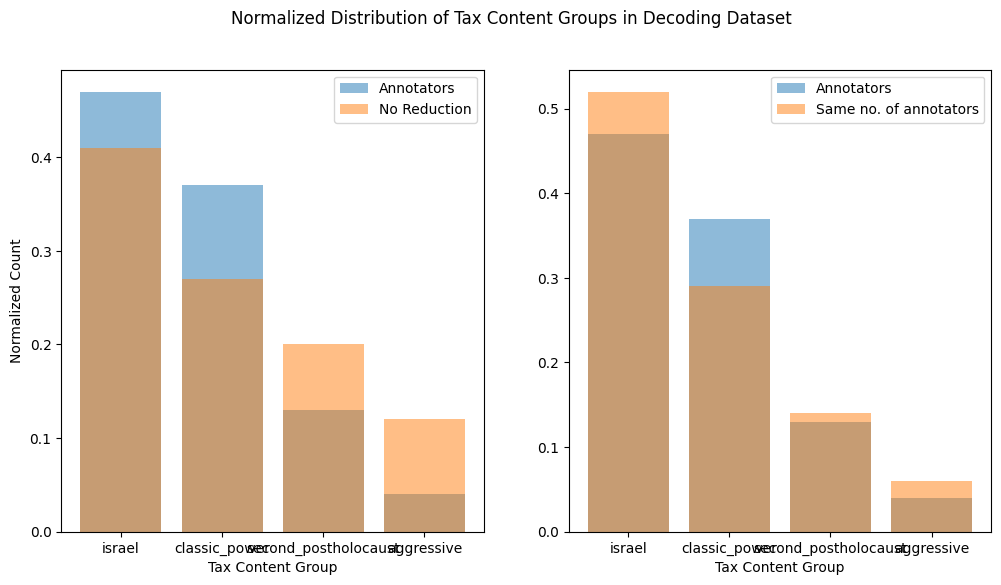

In [793]:
plot_distribution_diff_pair(
    d_tax_groups_count_norm,
    d_tax_e_groups_count_norm,
    d_tax_e_groups_same_count_norm,
    'No Reduction',
    'Same no. of annotators',
    'Normalized Distribution of Tax Content Groups in Decoding Dataset',
    'Tax Content Group',
    normalized=True)

In [794]:
compute_multilabel_prec_recall(decoding_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,92,453,80,0.869565,0.176600
1,classic_power,938,1009,675,0.719616,0.668979
3,israel,1192,1517,1153,0.967282,0.760053
2,second_postholocaust,332,745,260,0.783133,0.348993


### TAX_EX

In [798]:
decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex.head()

decoding_tax_ex['overlap'] = decoding_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
decoding_tax_ex['overlap'].mean()

np.float64(0.9412492269635127)

#### Group level

In [ ]:
decoding_tax_ex['explanation_same_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters_same'].map(group_lexicon_content)

In [ ]:
d_tax_ex_groups_count, d_tax_ex_groups_count_norm = count_items(decoding_tax_ex["annotators_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_count, d_tax_ex_e_groups_count_norm = count_items(decoding_tax_ex["explanation_content_groups"], interpret_as_int=False)
d_tax_ex_e_groups_same_count, d_tax_ex_e_groups_same_count_norm = count_items(decoding_tax_ex["explanation_same_content_groups"], interpret_as_int=False)

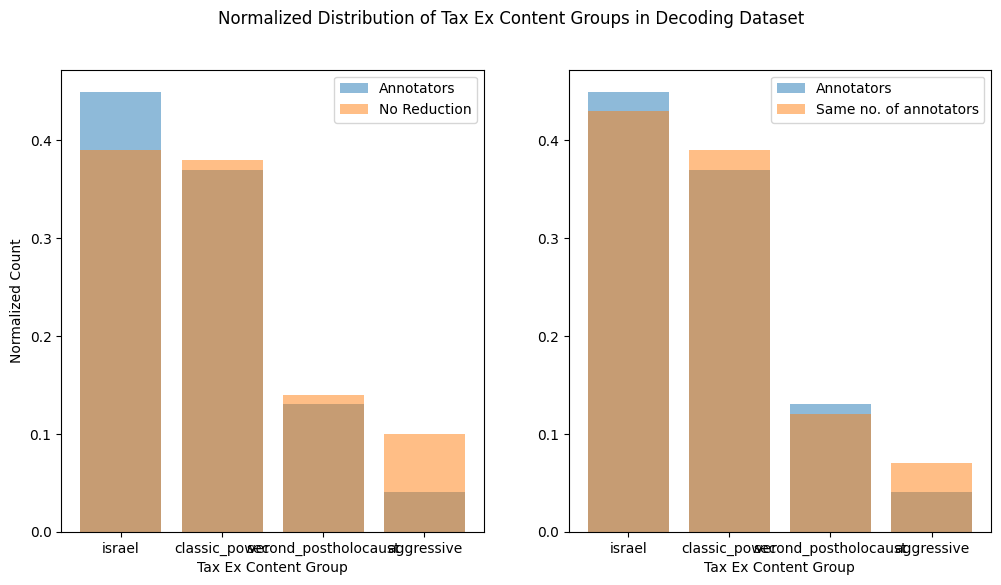

In [827]:
plot_distribution_diff_pair(
    d_tax_ex_groups_count_norm,
    d_tax_ex_e_groups_count_norm,
    d_tax_ex_e_groups_same_count_norm,
    'No Reduction',
    'Same no. of annotators',
    'Normalized Distribution of Tax Ex Content Groups in Decoding Dataset',
    'Tax Ex Content Group',
    normalized=True)

In [828]:
compute_multilabel_prec_recall(decoding_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,90,277,76,0.844444,0.274368
1,classic_power,757,1051,680,0.898283,0.647003
3,israel,924,1079,880,0.952381,0.815570
2,second_postholocaust,276,376,205,0.742754,0.545213


# DATASET UNION

## IHRA

In [832]:
bloomington_ihra = bloomington[bloomington['IHRA_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
bloomington_ihra["ihra_sections"] = bloomington_ihra["ihra_sections"].map(lambda x: [i for i in x if i!=13])  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
print(bloomington_ihra["ihra_sections"].value_counts())
bloomington_ihra['annotators_content_groups'] = bloomington_ihra['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra['explanation_content_groups'] = bloomington_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
bloomington_ihra["dataset_id"] = "b"
bloomington_ihra = bloomington_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

decoding_ihra = decoding[decoding['IHRA_c']=='Yes'][DECODING_DATA_COLS + ['IHRA_e', 'IHRA_e_sections']]
decoding_ihra['annotators_content_groups'] = decoding_ihra['comment_codes_all_chapters'].apply(group_lexicon_content)
decoding_ihra['explanation_content_groups'] = decoding_ihra['IHRA_e_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x])))
decoding_ihra["dataset_id"] = "d"
decoding_ihra = decoding_ihra[["comment_cleaned", "annotators_content_groups", "IHRA_e", "explanation_content_groups", "dataset_id"]]

# Now union ﷿﷿﷿ both dataframes already have annotators_content_groups
df_union_ihra = pd.concat([bloomington_ihra, decoding_ihra], ignore_index=True)
df_union_ihra.sample(2)


ihra_sections
[2]         316
[7]         191
[10]        167
[2, 10]      81
[0]          73
[10, 7]      64
[0, 10]      63
[9]          40
[9, 7]       22
[4]          21
[1]          19
[0, 2]       17
[10, 11]     17
[2, 3]       16
[10, 2]      14
[2, 7]       12
[3]          11
[1, 2]        7
[11]          7
[0, 1]        7
[11, 7]       6
[0, 7]        6
[2, 4]        6
[8, 7]        6
[9, 10]       5
[6]           5
[1, 10]       5
[3, 7]        4
[9, 2]        4
[10, 6]       3
[]            3
[10, 4]       3
[2, 6]        3
[2, 5]        3
[0, 9]        3
[2, 11]       3
[4, 5]        2
[10, 5]       2
[0, 4]        2
[1, 7]        2
[9, 11]       2
[10, 3]       2
[5]           2
[8]           1
[8, 9]        1
[1, 11]       1
[9, 6]        1
[1, 4]        1
[0, 3]        1
[4, 7]        1
[0, 6]        1
[8, 10]       1
Name: count, dtype: int64


,comment_cleaned,annotators_content_groups,IHRA_e,explanation_content_groups,dataset_id
2423,all we know zionnist jews are responsible for ...,[classic_power],The post contains multiple forms of antisemiti...,"[classic_power, israel]",d
24,"#USA, #Canada, #Israel a small KKK group again...",[israel],"The post groups Israel with the KKK, implying ...",[israel],b


In [833]:
df_union_ihra['overlap'] = df_union_ihra.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_ihra['overlap'].mean()



np.float64(0.905864774000747)

In [834]:
df_union_ihra["annotator_content_cnt"] = df_union_ihra["annotators_content_groups"].map(len)
df_union_ihra["model_content_count"] = df_union_ihra["explanation_content_groups"].map(len)
df_union_ihra[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,2677.000000,2677.000000
mean,1.242436,1.660067
std,0.483533,0.640167
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,3.000000,4.000000


#### Group level

In [835]:
u_ihra_groups_count, u_ihra_groups_count_norm = count_items(df_union_ihra["annotators_content_groups"], interpret_as_int=False)
u_ihra_e_groups_count, u_ihra_e_groups_count_norm = count_items(df_union_ihra["explanation_content_groups"], interpret_as_int=False)

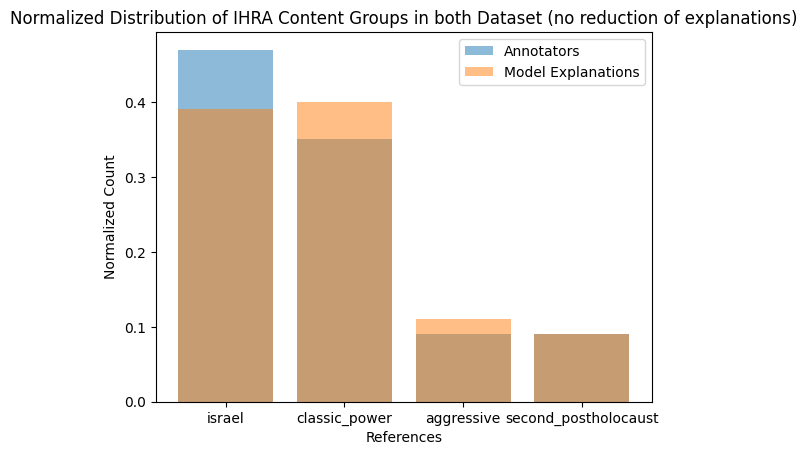

In [836]:
plot_distribution_diff(
    u_ihra_groups_count_norm, 
    u_ihra_e_groups_count_norm, 
    'Normalized Distribution of IHRA Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [837]:
compute_multilabel_prec_recall(df_union_ihra, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,290,493,139,0.479310,0.281947
1,classic_power,1179,1782,1038,0.880407,0.582492
3,israel,1547,1753,1437,0.928895,0.819738
2,second_postholocaust,310,416,139,0.448387,0.334135


## TAX

In [838]:
bloomington_tax = bloomington[bloomington['TAX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_e', 'TAX_e_chapters']]
bloomington_tax['annotators_content_groups'] = bloomington_tax['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax['explanation_content_groups'] = bloomington_tax['TAX_e_chapters'].map(group_lexicon_content)
bloomington_tax["dataset_id"] = "b"
bloomington_tax = bloomington_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax = decoding[decoding['TAX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_e', 'TAX_e_chapters', 'TAX_e_chapters_no', 'TAX_e_sections']]
decoding_tax['annotators_content_groups'] = decoding_tax['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax['explanation_content_groups'] = decoding_tax['TAX_e_chapters'].map(group_lexicon_content)
decoding_tax["dataset_id"] = "d"
decoding_tax = decoding_tax[["comment_cleaned", "annotators_content_groups", "TAX_e", "explanation_content_groups", "dataset_id"]]

# Now union ﷿﷿﷿ both dataframes already have annotators_content_groups
df_union_tax = pd.concat([bloomington_tax, decoding_tax], ignore_index=True)
df_union_tax.sample(2)

,comment_cleaned,annotators_content_groups,TAX_e,explanation_content_groups,dataset_id
2510,Israel is a colony of settlers built on the et...,[israel],The post frames Israel's founding as purely co...,"[second_postholocaust, israel]",d
1708,Total ADL annihilation,[aggressive],The phrase 'Total ADL annihilation' is a call ...,"[aggressive, classic_power]",d


In [841]:
df_union_tax['overlap'] = df_union_tax.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax['overlap'].mean()

np.float64(0.9273775216138328)

In [842]:
df_union_tax["annotator_content_cnt"] = df_union_tax["annotators_content_groups"].map(len)
df_union_tax["model_content_count"] = df_union_tax["explanation_content_groups"].map(len)
df_union_tax[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,3470.000000,3470.000000
mean,1.236888,1.870605
std,0.482402,0.778587
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,4.000000,4.000000


#### Group level

In [843]:
u_tax_groups_count, u_tax_groups_count_norm = count_items(df_union_tax["annotators_content_groups"], interpret_as_int=False)
u_tax_e_groups_count, u_tax_e_groups_count_norm = count_items(df_union_tax["explanation_content_groups"], interpret_as_int=False)
print(u_tax_groups_count)
print(u_tax_e_groups_count)

Counter({'israel': 2106, 'classic_power': 1465, 'second_postholocaust': 418, 'aggressive': 303})
Counter({'israel': 2456, 'classic_power': 1937, 'second_postholocaust': 1188, 'aggressive': 910})


In [844]:
# get all unique items across all lists
all_items = set(item for sublist in df_union_tax["annotators_content_groups"] if isinstance(sublist, list) for item in sublist)
print(all_items)

{'aggressive', 'classic_power', 'second_postholocaust', 'israel'}


In [845]:
for item in all_items:
    result = group_ihra_content(item)  # or group_lexicon_content, whichever is relevant here
    if result is None:
        print(f"Input '{item}' maps to None")

Input 'aggressive' maps to None
Input 'classic_power' maps to None
Input 'second_postholocaust' maps to None
Input 'israel' maps to None


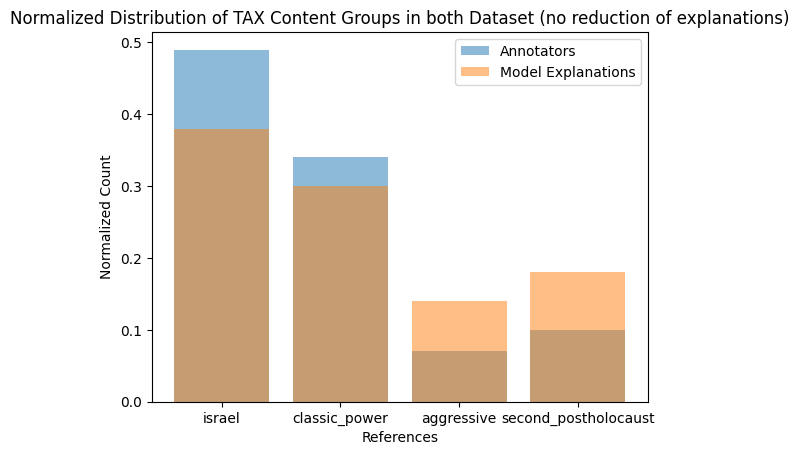

In [846]:
plot_distribution_diff(
    u_tax_groups_count_norm, 
    u_tax_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [847]:
compute_multilabel_prec_recall(df_union_tax, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,303,910,241,0.795380,0.264835
1,classic_power,1465,1937,1154,0.787713,0.595767
3,israel,2106,2456,2006,0.952517,0.816775
2,second_postholocaust,418,1188,329,0.787081,0.276936


## TAX_EX

In [848]:
bloomington_tax_ex = bloomington[bloomington['TAX_EX_c']=='Yes'][BLOOMINGTON_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters']]
bloomington_tax_ex['annotators_content_groups'] = bloomington_tax_ex['ihra_sections'].apply(lambda x: list(set([group_ihra_content(item) for item in x if item!=13])))  # Remove section 13 as it is not part of the IHRA definition (errors in section-level annotations)
bloomington_tax_ex['explanation_content_groups'] = bloomington_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
bloomington_tax_ex["dataset_id"] = "b"
bloomington_tax_ex = bloomington_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

decoding_tax_ex = decoding[decoding['TAX_EX_c']=='Yes'][DECODING_DATA_COLS + ['TAX_EX_e', 'TAX_EX_e_chapters', 'TAX_EX_e_chapters_no', 'TAX_EX_e_sections']]
decoding_tax_ex['annotators_content_groups'] = decoding_tax_ex['comment_codes_all_chapters'].map(group_lexicon_content)
decoding_tax_ex['explanation_content_groups'] = decoding_tax_ex['TAX_EX_e_chapters'].map(group_lexicon_content)
decoding_tax_ex["dataset_id"] = "d"
decoding_tax_ex = decoding_tax_ex[["comment_cleaned", "annotators_content_groups", "TAX_EX_e", "explanation_content_groups", "dataset_id"]]

# Now union ﷿﷿﷿ both dataframes already have annotators_content_groups
df_union_tax_ex = pd.concat([bloomington_tax_ex, decoding_tax_ex], ignore_index=True)
df_union_tax_ex.sample(2)

,comment_cleaned,annotators_content_groups,TAX_EX_e,explanation_content_groups,dataset_id
2443,Well done Sally Rooney. The Israeli state is a...,"[classic_power, israel]",This post combines multiple antisemitic tropes...,[israel],d
131,73 years occupation will end and you will be s...,[israel],The post combines multiple antisemitic tropes....,"[aggressive, classic_power, israel]",b


In [849]:
df_union_tax_ex['overlap'] = df_union_tax_ex.apply(
    lambda row: 1 if set(row['annotators_content_groups']) & set(row['explanation_content_groups']) else 0,
    axis=1
)
df_union_tax_ex['overlap'].mean()

np.float64(0.9334698055271239)

In [850]:
df_union_tax_ex["annotator_content_cnt"] = df_union_tax_ex["annotators_content_groups"].map(len)
df_union_tax_ex["model_content_count"] = df_union_tax_ex["explanation_content_groups"].map(len)
df_union_tax_ex[["annotator_content_cnt", "model_content_count"]].describe()

,annotator_content_cnt,model_content_count
count,2931.000000,2931.000000
mean,1.236438,1.732515
std,0.484979,0.692301
min,0.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,4.000000,4.000000


#### Group level

In [851]:
u_tax_ex_groups_count, u_tax_ex_groups_count_norm = count_items(df_union_tax_ex["annotators_content_groups"], interpret_as_int=False)
u_tax_ex_e_groups_count, u_tax_ex_e_groups_count_norm = count_items(df_union_tax_ex["explanation_content_groups"], interpret_as_int=False)
print(u_tax_ex_groups_count)

Counter({'israel': 1713, 'classic_power': 1264, 'second_postholocaust': 352, 'aggressive': 295})


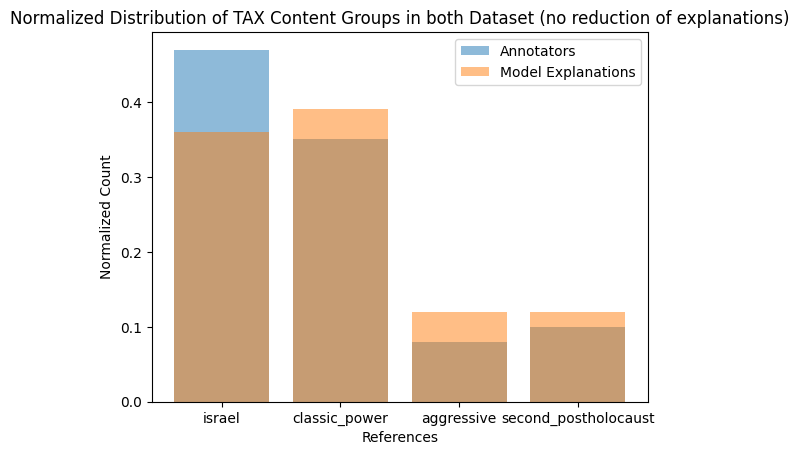

In [852]:
plot_distribution_diff(
    u_tax_ex_groups_count_norm, 
    u_tax_ex_e_groups_count_norm, 
    'Normalized Distribution of TAX Content Groups in both Dataset (no reduction of explanations)', 
    normalized=True)

Calculate recall (how often did the model correctly identify a specific content group that was labeled by annotators) as well as precision (how often did the model correctly name the content group as an explanation of a post being antisemitic)

In [853]:
compute_multilabel_prec_recall(df_union_tax_ex, 'annotators_content_groups', 'explanation_content_groups')

,content_group,annotators_identified,model_identified,both_identified,recall,precision
0,aggressive,295,623,208,0.705085,0.333868
1,classic_power,1264,1991,1154,0.912975,0.579608
3,israel,1713,1849,1599,0.933450,0.864792
2,second_postholocaust,352,615,258,0.732955,0.419512
